# Pre-Final Notebook — Fraud Risk → Business Action
### IEEE-CIS primary · multi-model · 5-seed mean±std · PCA/UMAP · cost policy

**Includes**
- Composite entity key + leakage-safe behavioral features
- Temporal train/val/test split (no random leakage)
- LightGBM + XGBoost + RandomForest
- **5 seeds** with results as **mean ± std**
- **VAL-tuned F1 threshold** (fixes Precision/Recall/F1/MCC = 0 at thr=0.5)
- Soft ensemble of seed-averaged / model-averaged scores
- PCA + UMAP with fraud emphasis + covariance ellipse
- Cost-sensitive APPROVE / REVIEW / BLOCK + FC@budget
- Optional SHAP

**Metrics note:** PR-AUC / ROC-AUC are ranking metrics. Precision/Recall/F1/MCC use a threshold chosen on VAL (max F1), then applied to TEST.


## 0. Setup


In [20]:
import os, gc, json, time, warnings
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import EmpiricalCovariance
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef, precision_recall_curve,
)

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("Install lightgbm")

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost optional")

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("Optional: !pip install umap-learn")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

RANDOM_STATE = 42
SEEDS = [42, 7, 123, 2024, 99]
np.random.seed(RANDOM_STATE)

def rss_mb():
    try:
        with open("/proc/self/status") as f:
            for line in f:
                if line.startswith("VmRSS:"):
                    return int(line.split()[1]) / 1024.0
    except Exception:
        pass
    return -1.0

print(f"LGB={HAS_LGB} XGB={HAS_XGB} UMAP={HAS_UMAP} SHAP={HAS_SHAP} RSS={rss_mb():.0f}")


LGB=True XGB=True UMAP=True SHAP=True RSS=6637


In [21]:
CONFIG = {
    "ieee_transaction_path": "/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv",
    "ieee_identity_path": "/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv",

    # 300k default; set None for full data on high-RAM
    "SAMPLE_N_IEEE": 300_000,

    "train_frac": 0.60,
    "val_frac": 0.20,
    "test_frac": 0.20,

    "drop_high_missing": True,
    "high_missing_threshold": 0.92,
    "velocity_windows": [3600 * h for h in [1, 6, 12, 24, 72, 168]],

    "output_dir": "/kaggle/working/outputs_prefinal",
    "feat_parquet": "/kaggle/working/outputs_prefinal/ieee_feat.parquet",
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if "path" not in k}, indent=2))


{
  "SAMPLE_N_IEEE": 300000,
  "train_frac": 0.6,
  "val_frac": 0.2,
  "test_frac": 0.2,
  "drop_high_missing": true,
  "high_missing_threshold": 0.92,
  "velocity_windows": [
    3600,
    21600,
    43200,
    86400,
    259200,
    604800
  ],
  "output_dir": "/kaggle/working/outputs_prefinal",
  "feat_parquet": "/kaggle/working/outputs_prefinal/ieee_feat.parquet"
}


## 1. Load IEEE-CIS + composite entity


In [22]:
def downcast_df(df):
    for c in df.select_dtypes(include=["float64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="float")
    for c in df.select_dtypes(include=["int64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="integer")
    return df

def load_ieee(config):
    t0 = time.time()
    nrows = config["SAMPLE_N_IEEE"]
    print(f"Loading transaction nrows={nrows}...", flush=True)
    df = pd.read_csv(config["ieee_transaction_path"], nrows=nrows)
    df = downcast_df(df)

    ident_path = Path(config["ieee_identity_path"])
    if ident_path.exists():
        ids = set(df["TransactionID"].values)
        chunks = []
        for ch in pd.read_csv(ident_path, chunksize=250_000):
            ch = ch[ch["TransactionID"].isin(ids)]
            if len(ch):
                chunks.append(ch)
        if chunks:
            ident = downcast_df(pd.concat(chunks, ignore_index=True))
            df = df.merge(ident, on="TransactionID", how="left")
            del ident, chunks
            gc.collect()

    if config.get("drop_high_missing"):
        thr = config["high_missing_threshold"]
        miss = df.isna().mean()
        protect = {
            "isFraud", "TransactionID", "TransactionDT", "TransactionAmt",
            "card1", "addr1", "P_emaildomain", "ProductCD",
        }
        drop = [c for c in miss.index if miss[c] > thr and c not in protect]
        print(f"Drop {len(drop)} high-missing cols", flush=True)
        df = df.drop(columns=drop)

    parts = [df["card1"].astype(str).fillna("NA")]
    if "addr1" in df.columns:
        parts.append(df["addr1"].astype(str).fillna("NA"))
    if "P_emaildomain" in df.columns:
        parts.append(df["P_emaildomain"].astype(str).fillna("NA"))
    df["entity_key"] = parts[0]
    for p in parts[1:]:
        df["entity_key"] = df["entity_key"] + "|" + p

    df = df.sort_values("TransactionDT").reset_index(drop=True)
    df = downcast_df(df)
    print(f"Loaded {df.shape} fraud={df['isFraud'].mean()*100:.3f}% in {time.time()-t0:.1f}s RSS={rss_mb():.0f}")
    return df

df = load_ieee(CONFIG)


Loading transaction nrows=300000...
Drop 10 high-missing cols
Loaded (300000, 425) fraud=3.366% in 19.3s RSS=7195


## 2. Leakage-safe behavioral features


In [23]:
def add_behavioral_features(df, entity_col="entity_key", amount_col="TransactionAmt",
                            time_col="TransactionDT", windows=None, eps=1e-6):
    windows = windows or CONFIG["velocity_windows"]
    t0 = time.time()
    df = df.sort_values(time_col).reset_index(drop=True)
    g = df.groupby(entity_col, sort=False)

    df["beh_prev_tx_count"] = g.cumcount().astype(np.int32)
    shifted = g[amount_col].shift(1)
    past_cnt = df["beh_prev_tx_count"].astype(np.float32)
    past_sum = shifted.fillna(0).groupby(df[entity_col], sort=False).cumsum()
    df["beh_prev_amount_mean"] = np.where(past_cnt > 0, past_sum / past_cnt, np.nan).astype(np.float32)

    past_sum_sq = (shifted ** 2).fillna(0).groupby(df[entity_col], sort=False).cumsum()
    mean_sq = np.where(past_cnt > 0, past_sum_sq / past_cnt, np.nan)
    var = np.maximum(mean_sq - df["beh_prev_amount_mean"].astype(np.float64) ** 2, 0)
    df["beh_prev_amount_std"] = np.sqrt(var).astype(np.float32).fillna(0)

    df["beh_amount_zscore"] = ((df[amount_col] - df["beh_prev_amount_mean"]) / (df["beh_prev_amount_std"] + eps)).astype(np.float32)
    df["beh_amount_ratio"] = (df[amount_col] / (df["beh_prev_amount_mean"] + eps)).astype(np.float32)
    first = df["beh_prev_tx_count"] == 0
    df.loc[first, ["beh_amount_zscore", "beh_amount_ratio"]] = 0.0
    df["beh_amount_ratio"] = df["beh_amount_ratio"].replace([np.inf, -np.inf], np.nan)
    med = df["beh_amount_ratio"].median()
    df["beh_amount_ratio"] = df["beh_amount_ratio"].fillna(med if pd.notna(med) else 1.0)

    df["beh_time_since_prev"] = (df[time_col] - g[time_col].shift(1)).astype(np.float32)
    mx = df["beh_time_since_prev"].max()
    df["beh_time_since_prev"] = df["beh_time_since_prev"].fillna(mx if pd.notna(mx) else 0)

    df["beh_log_amount"] = np.log1p(df[amount_col].astype(np.float32))
    tod = (df[time_col] % 86400).astype(np.float32)
    df["beh_hour_sin"] = np.sin(2 * np.pi * tod / 86400).astype(np.float32)
    df["beh_hour_cos"] = np.cos(2 * np.pi * tod / 86400).astype(np.float32)
    df["beh_dow_sin"] = np.sin(2 * np.pi * (df[time_col] % (86400 * 7)) / (86400 * 7)).astype(np.float32)
    df["beh_dow_cos"] = np.cos(2 * np.pi * (df[time_col] % (86400 * 7)) / (86400 * 7)).astype(np.float32)

    if "isFraud" in df.columns:
        shifted_y = g["isFraud"].shift(1)
        past_fraud_sum = shifted_y.fillna(0).groupby(df[entity_col], sort=False).cumsum()
        df["beh_prev_fraud_rate"] = np.where(past_cnt > 0, past_fraud_sum / past_cnt, 0).astype(np.float32)
        df["beh_prev_fraud_count"] = past_fraud_sum.astype(np.float32)

    print("  velocity...", flush=True)
    entities = df[entity_col].fillna("__NA__").values
    times = df[time_col].values
    order = np.argsort(entities, kind="stable")
    ent_vals, t_vals = entities[order], times[order]
    for w in windows:
        counts = np.zeros(len(df), dtype=np.int32)
        n, i = len(df), 0
        while i < n:
            j = i
            while j < n and ent_vals[j] == ent_vals[i]:
                j += 1
            sub = t_vals[i:j]
            lo = 0
            for k in range(len(sub)):
                cutoff = sub[k] - w
                while lo < k and sub[lo] < cutoff:
                    lo += 1
                counts[i + k] = k - lo
            i = j
        out = np.empty(len(df), dtype=np.int32)
        out[order] = counts
        df[f"beh_velocity_{w}s"] = out

    print(f"  done {time.time()-t0:.1f}s shape={df.shape} RSS={rss_mb():.0f}")
    return df

df = add_behavioral_features(df)
df.to_parquet(CONFIG["feat_parquet"], index=False)
print("Saved", CONFIG["feat_parquet"])
del df
gc.collect()


  velocity...
  done 3.1s shape=(300000, 444) RSS=7175
Saved /kaggle/working/outputs_prefinal/ieee_feat.parquet


0

## 3. Temporal split + preprocess


In [24]:
df = pd.read_parquet(CONFIG["feat_parquet"])
print("Loaded", df.shape, f"RSS={rss_mb():.0f}")

def temporal_split(df, time_col="TransactionDT"):
    df = df.sort_values(time_col).reset_index(drop=True)
    n = len(df)
    a = int(n * CONFIG["train_frac"])
    b = int(n * (CONFIG["train_frac"] + CONFIG["val_frac"]))
    tr, va, te = df.iloc[:a].copy(), df.iloc[a:b].copy(), df.iloc[b:].copy()
    for name, d in [("train", tr), ("val", va), ("test", te)]:
        print(f"  {name}: {len(d):,} fraud={d['isFraud'].mean()*100:.3f}%")
    return tr, va, te

train_df, val_df, test_df = temporal_split(df)
del df
gc.collect()


Loaded (300000, 444) RSS=6867
  train: 180,000 fraud=2.856%
  val: 60,000 fraud=4.380%
  test: 60,000 fraud=3.883%


0

In [25]:
def build_feature_list(frame):
    core = [c for c in [
        "TransactionAmt", "ProductCD", "card1", "card2", "card3", "card4", "card5", "card6",
        "addr1", "addr2", "dist1", "dist2", "P_emaildomain", "R_emaildomain",
        "DeviceType", "DeviceInfo",
    ] if c in frame.columns]
    groups = []
    for prefix in ("C", "D", "V", "M", "id_"):
        groups += [c for c in frame.columns if c.startswith(prefix)]
    beh = [c for c in frame.columns if c.startswith("beh_")]
    ban = {"TransactionID", "isFraud", "TransactionDT", "entity_key"}
    feats, seen = [], set()
    for c in core + groups + beh:
        if c not in ban and c not in seen and c in frame.columns:
            seen.add(c)
            feats.append(c)
    return feats

FEATURE_COLS = build_feature_list(train_df)
print("n_features", len(FEATURE_COLS))

class Preprocessor:
    def __init__(self, cols, miss_thr=0.5):
        self.cols = cols
        self.miss_thr = miss_thr
        self.cat_cols, self.num_cols, self.flag_cols = [], [], []
        self.freq, self.med = {}, {}

    def fit(self, d):
        self.cols = [c for c in self.cols if c in d.columns]
        self.cat_cols = [c for c in self.cols if d[c].dtype == object or str(d[c].dtype) == "category"]
        self.num_cols = [c for c in self.cols if c not in self.cat_cols]
        miss = d[self.cols].isna().mean()
        self.flag_cols = miss[miss > self.miss_thr].index.tolist()
        for c in self.cat_cols:
            self.freq[c] = d[c].astype(str).value_counts(normalize=True).to_dict()
        for c in self.num_cols:
            self.med[c] = float(d[c].median()) if d[c].notna().any() else 0.0
        return self

    def transform(self, d):
        n = len(d)
        data = {}
        for c in self.flag_cols:
            data[f"{c}_miss"] = d[c].isna().astype(np.float32).values if c in d.columns else np.zeros(n, np.float32)
        for c in self.cat_cols:
            m = self.freq.get(c, {})
            data[c] = d[c].astype(str).map(m).fillna(0).astype(np.float32).values if c in d.columns else np.zeros(n, np.float32)
        for c in self.num_cols:
            med = self.med.get(c, 0.0)
            data[c] = d[c].fillna(med).astype(np.float32).values if c in d.columns else np.full(n, med, np.float32)
        return pd.DataFrame(data, index=d.index)

prep = Preprocessor(FEATURE_COLS).fit(train_df)
X_train = prep.transform(train_df)
X_val = prep.transform(val_df)
X_test = prep.transform(test_df)
y_train = train_df["isFraud"].values.astype(np.int8)
y_val = val_df["isFraud"].values.astype(np.int8)
y_test = test_df["isFraud"].values.astype(np.int8)
print(X_train.shape, X_val.shape, X_test.shape, f"RSS={rss_mb():.0f}")


n_features 440
(180000, 662) (60000, 662) (60000, 662) RSS=5856


## 4. Metrics helpers (VAL-tuned threshold)

**Do not use thr=0.5 for F1/MCC on this imbalance** — probabilities are often all < 0.5 → fake zeros.


In [26]:
def best_f1_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    return float(thr[int(np.nanargmax(f1))])

def metrics_at_threshold(y_true, proba, thr):
    pred = (proba >= thr).astype(int)
    return {
        "PR_AUC": float(average_precision_score(y_true, proba)),
        "ROC_AUC": float(roc_auc_score(y_true, proba)),
        "Precision": float(precision_score(y_true, pred, zero_division=0)),
        "Recall": float(recall_score(y_true, pred, zero_division=0)),
        "F1": float(f1_score(y_true, pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, pred)),
        "threshold": float(thr),
    }

def fc_at_budget(y_true, proba, fracs=(0.01, 0.05, 0.10)):
    order = np.argsort(-proba)
    y_s = y_true[order]
    tot = max(float(y_true.sum()), 1.0)
    out = {}
    for b in fracs:
        k = max(int(np.ceil(len(y_true) * b)), 1)
        out[f"FC@{int(b*100)}%"] = float(y_s[:k].sum() / tot)
    return out

pos_w = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
print("pos_weight", round(pos_w, 2))


pos_weight 34.01


## 5. Multi-model × 5-seed runs → mean ± std


In [27]:
def make_models(seed):
    models = {}
    if HAS_LGB:
        models["LightGBM"] = lgb.LGBMClassifier(
            n_estimators=600, num_leaves=63, learning_rate=0.03,
            subsample=0.85, colsample_bytree=0.7, min_child_samples=30,
            reg_lambda=1.5, scale_pos_weight=pos_w,
            random_state=seed, n_jobs=-1, verbose=-1,
        )
    if HAS_XGB:
        models["XGBoost"] = xgb.XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.03,
            subsample=0.85, colsample_bytree=0.7, min_child_weight=5,
            reg_lambda=2.0, scale_pos_weight=pos_w,
            eval_metric="aucpr", random_state=seed, n_jobs=-1, tree_method="hist",
        )
    models["RandomForest"] = RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=20,
        class_weight="balanced_subsample", max_features="sqrt",
        random_state=seed, n_jobs=-1,
    )
    return models

rows = []
# store test probas for ensemble: key (model, seed)
proba_store = {}

for seed in SEEDS:
    print(f"\n===== SEED {seed} =====", flush=True)
    for name, model in make_models(seed).items():
        print(f"  fit {name}...", flush=True)
        t0 = time.time()
        if name == "LightGBM":
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric="average_precision",
                callbacks=[lgb.early_stopping(50, verbose=False)],
            )
        else:
            model.fit(X_train, y_train)
        pv = model.predict_proba(X_val)[:, 1]
        pt = model.predict_proba(X_test)[:, 1]
        thr = best_f1_threshold(y_val, pv)
        m = metrics_at_threshold(y_test, pt, thr)
        m.update(fc_at_budget(y_test, pt))
        m["seed"] = seed
        m["model"] = name
        m["split"] = "TEST"
        m["fit_s"] = round(time.time() - t0, 1)
        rows.append(m)
        proba_store[(name, seed)] = pt
        print(f"    thr={thr:.3f} PR-AUC={m['PR_AUC']:.4f} ROC={m['ROC_AUC']:.4f} "
              f"F1={m['F1']:.4f} MCC={m['MCC']:.4f} Rec={m['Recall']:.4f}")
        gc.collect()

df_raw = pd.DataFrame(rows)
df_raw.to_csv(f"{CONFIG['output_dir']}/multimodel_5seed_raw.csv", index=False)
print("\nRaw runs saved.")
df_raw.head(10)



===== SEED 42 =====
  fit LightGBM...
    thr=0.200 PR-AUC=0.5621 ROC=0.9367 F1=0.5753 MCC=0.5590 Rec=0.5579
  fit XGBoost...
    thr=0.854 PR-AUC=0.7216 ROC=0.9438 F1=0.6810 MCC=0.6755 Rec=0.6052
  fit RandomForest...
    thr=0.635 PR-AUC=0.6204 ROC=0.9265 F1=0.5795 MCC=0.5624 Rec=0.5841

===== SEED 7 =====
  fit LightGBM...
    thr=0.198 PR-AUC=0.5419 ROC=0.9334 F1=0.5524 MCC=0.5341 Rec=0.5644
  fit XGBoost...
    thr=0.833 PR-AUC=0.7201 ROC=0.9430 F1=0.6785 MCC=0.6695 Rec=0.6236
  fit RandomForest...
    thr=0.640 PR-AUC=0.6175 ROC=0.9265 F1=0.5738 MCC=0.5565 Rec=0.5742

===== SEED 123 =====
  fit LightGBM...
    thr=0.193 PR-AUC=0.5676 ROC=0.9349 F1=0.5663 MCC=0.5505 Rec=0.5386
  fit XGBoost...
    thr=0.839 PR-AUC=0.7175 ROC=0.9414 F1=0.6779 MCC=0.6704 Rec=0.6129
  fit RandomForest...
    thr=0.676 PR-AUC=0.6232 ROC=0.9273 F1=0.5874 MCC=0.5738 Rec=0.5459

===== SEED 2024 =====
  fit LightGBM...
    thr=0.205 PR-AUC=0.5535 ROC=0.9349 F1=0.5638 MCC=0.5576 Rec=0.4833
  fit XGBoost..

,PR_AUC,ROC_AUC,Precision,Recall,F1,MCC,threshold,FC@1%,FC@5%,FC@10%,seed,model,split,fit_s
0,0.562119,0.936682,0.593878,0.557940,0.575349,0.559042,0.199644,0.213305,0.643348,0.798712,42,LightGBM,TEST,20.7
1,0.721607,0.943764,0.778575,0.605150,0.680995,0.675488,0.853543,0.254077,0.707296,0.812017,42,XGBoost,TEST,76.7
2,0.620412,0.926541,0.574989,0.584120,0.579519,0.562410,0.634560,0.239056,0.642918,0.767811,42,RandomForest,TEST,56.3
3,0.541857,0.933392,0.540930,0.564378,0.552405,0.534052,0.198258,0.204292,0.621459,0.766094,7,LightGBM,TEST,20.4
4,0.720136,0.943039,0.743984,0.623605,0.678496,0.669486,0.833194,0.253219,0.708584,0.813734,7,XGBoost,TEST,77.0
5,0.617489,0.926507,0.573265,0.574249,0.573756,0.556520,0.640326,0.237339,0.638197,0.769957,7,RandomForest,TEST,55.7
6,0.567648,0.934950,0.597050,0.538627,0.566336,0.550536,0.193304,0.215880,0.615451,0.765236,123,LightGBM,TEST,20.6
7,0.717513,0.941433,0.758364,0.612876,0.677902,0.670381,0.839169,0.252790,0.698283,0.813734,123,XGBoost,TEST,76.3
8,0.623168,0.927259,0.635682,0.545923,0.587393,0.573820,0.675703,0.237339,0.647210,0.772532,123,RandomForest,TEST,57.8
9,0.553521,0.934866,0.676683,0.483262,0.563846,0.557603,0.204510,0.209871,0.612017,0.788841,2024,LightGBM,TEST,20.3


In [28]:
metric_cols = ["PR_AUC", "ROC_AUC", "Precision", "Recall", "F1", "MCC",
               "FC@1%", "FC@5%", "FC@10%", "threshold"]
metric_cols = [c for c in metric_cols if c in df_raw.columns]

wide = []
print("=" * 72)
print("TEST mean ± std by model (5 seeds, VAL max-F1 threshold)")
print("=" * 72)
for model_name, g in df_raw.groupby("model"):
    row = {"model": model_name}
    print(f"\n### {model_name}")
    for c in metric_cols:
        mu, sd = g[c].mean(), g[c].std(ddof=1)
        s = f"{mu:.4f} ± {sd:.4f}"
        row[c] = s
        print(f"  {c:12s}  {s}")
    wide.append(row)

df_mean_std = pd.DataFrame(wide)
df_mean_std.to_csv(f"{CONFIG['output_dir']}/multimodel_5seed_mean_std.csv", index=False)
print("\n")
display(df_mean_std)

# thesis copy-paste
print("\n--- Thesis lines (TEST) ---")
for _, r in df_mean_std.iterrows():
    print(f"{r['model']}: PR-AUC {r['PR_AUC']}, ROC-AUC {r['ROC_AUC']}, MCC {r['MCC']}")


TEST mean ± std by model (5 seeds, VAL max-F1 threshold)

### LightGBM
  PR_AUC        0.5562 ± 0.0097
  ROC_AUC       0.9349 ± 0.0012
  Precision     0.6055 ± 0.0490
  Recall        0.5416 ± 0.0343
  F1            0.5696 ± 0.0141
  MCC           0.5553 ± 0.0149
  FC@1%         0.2090 ± 0.0060
  FC@5%         0.6257 ± 0.0135
  FC@10%        0.7778 ± 0.0151
  threshold     0.1991 ± 0.0040

### RandomForest
  PR_AUC        0.6172 ± 0.0053
  ROC_AUC       0.9265 ± 0.0005
  Precision     0.5910 ± 0.0415
  Recall        0.5700 ± 0.0250
  F1            0.5788 ± 0.0076
  MCC           0.5629 ± 0.0094
  FC@1%         0.2370 ± 0.0016
  FC@5%         0.6404 ± 0.0056
  FC@10%        0.7693 ± 0.0022
  threshold     0.6474 ± 0.0269

### XGBoost
  PR_AUC        0.7197 ± 0.0022
  ROC_AUC       0.9429 ± 0.0010
  Precision     0.7633 ± 0.0158
  Recall        0.6140 ± 0.0094
  F1            0.6804 ± 0.0022
  MCC           0.6733 ± 0.0031
  FC@1%         0.2533 ± 0.0006
  FC@5%         0.7051 ± 0.0040
  

,model,PR_AUC,ROC_AUC,Precision,Recall,F1,MCC,FC@1%,FC@5%,FC@10%,threshold
0,LightGBM,0.5562 ± 0.0097,0.9349 ± 0.0012,0.6055 ± 0.0490,0.5416 ± 0.0343,0.5696 ± 0.0141,0.5553 ± 0.0149,0.2090 ± 0.0060,0.6257 ± 0.0135,0.7778 ± 0.0151,0.1991 ± 0.0040
1,RandomForest,0.6172 ± 0.0053,0.9265 ± 0.0005,0.5910 ± 0.0415,0.5700 ± 0.0250,0.5788 ± 0.0076,0.5629 ± 0.0094,0.2370 ± 0.0016,0.6404 ± 0.0056,0.7693 ± 0.0022,0.6474 ± 0.0269
2,XGBoost,0.7197 ± 0.0022,0.9429 ± 0.0010,0.7633 ± 0.0158,0.6140 ± 0.0094,0.6804 ± 0.0022,0.6733 ± 0.0031,0.2533 ± 0.0006,0.7051 ± 0.0040,0.8120 ± 0.0040,0.8418 ± 0.0123



--- Thesis lines (TEST) ---
LightGBM: PR-AUC 0.5562 ± 0.0097, ROC-AUC 0.9349 ± 0.0012, MCC 0.5553 ± 0.0149
RandomForest: PR-AUC 0.6172 ± 0.0053, ROC-AUC 0.9265 ± 0.0005, MCC 0.5629 ± 0.0094
XGBoost: PR-AUC 0.7197 ± 0.0022, ROC-AUC 0.9429 ± 0.0010, MCC 0.6733 ± 0.0031


## 6. Soft ensemble (mean of model means across seeds)


In [29]:
# Average proba across seeds per model, then average models
model_names = sorted({k[0] for k in proba_store})
model_avg = {}
for name in model_names:
    mats = [proba_store[(name, s)] for s in SEEDS if (name, s) in proba_store]
    model_avg[name] = np.mean(np.vstack(mats), axis=0)

# equal blend of available models
ens_proba = np.mean(np.vstack([model_avg[n] for n in model_names]), axis=0)
# threshold from averaging VAL is harder without storing val proba — use mean of model thresholds
mean_thr = float(df_raw.groupby("model")["threshold"].mean().mean())
ens = metrics_at_threshold(y_test, ens_proba, mean_thr)
ens.update(fc_at_budget(y_test, ens_proba))
ens["threshold"] = mean_thr
print("ENSEMBLE (seed-avg then model-avg) TEST:")
for k, v in ens.items():
    print(f"  {k}: {v if not isinstance(v, float) else round(v, 4)}")

# Best single model by mean PR-AUC
best_model = df_mean_std.assign(
    pr=df_mean_std["PR_AUC"].str.split(" ").str[0].astype(float)
).sort_values("pr", ascending=False).iloc[0]["model"]
print("Best model by mean PR-AUC:", best_model)
proba_best = model_avg[best_model]


ENSEMBLE (seed-avg then model-avg) TEST:
  PR_AUC: 0.691
  ROC_AUC: 0.9431
  Precision: 0.7299
  Recall: 0.5948
  F1: 0.6555
  MCC: 0.6466
  threshold: 0.5628
  FC@1%: 0.2446
  FC@5%: 0.6987
  FC@10%: 0.8142
Best model by mean PR-AUC: XGBoost


## 7. PCA + UMAP — emphasize fraud cluster


PCA var explained (2D): 41.2%


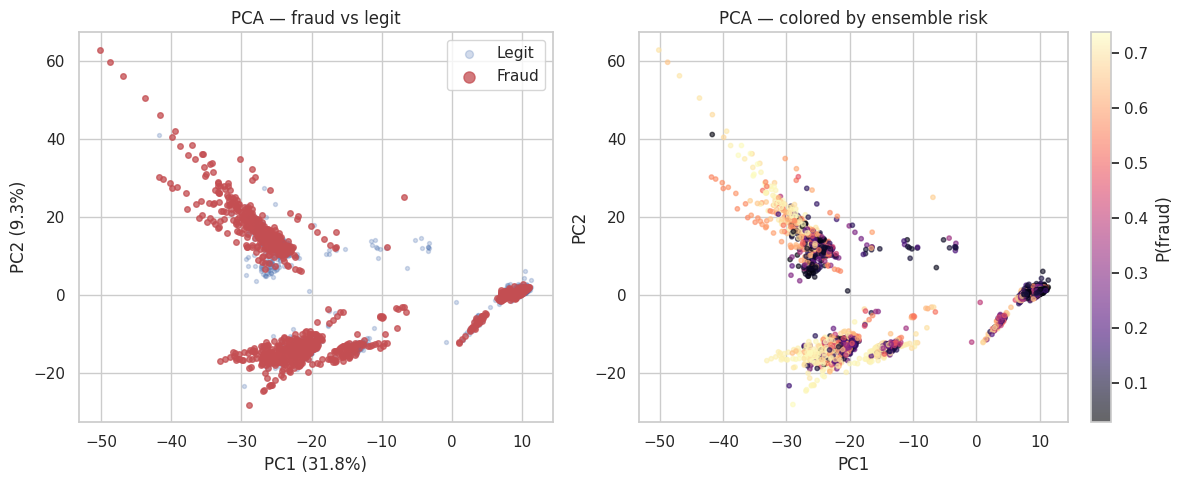

In [30]:
rng = np.random.RandomState(42)
fraud_idx = np.where(y_test == 1)[0]
legit_idx = np.where(y_test == 0)[0]
n_fraud_viz = min(len(fraud_idx), 2000)
n_legit_viz = min(len(legit_idx), 6000)
viz_idx = np.concatenate([
    rng.choice(fraud_idx, n_fraud_viz, replace=False),
    rng.choice(legit_idx, n_legit_viz, replace=False),
])
rng.shuffle(viz_idx)

X_viz = X_test.iloc[viz_idx]
y_viz = y_test[viz_idx]
risk_viz = ens_proba[viz_idx]

scaler_v = StandardScaler()
X_scaled = scaler_v.fit_transform(X_viz)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA var explained (2D): {pca.explained_variance_ratio_.sum()*100:.1f}%")

leg = y_viz == 0
fr = y_viz == 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.scatter(X_pca[leg, 0], X_pca[leg, 1], c="#4C72B0", s=8, alpha=0.25, label="Legit", rasterized=True)
ax.scatter(X_pca[fr, 0], X_pca[fr, 1], c="#C44E52", s=16, alpha=0.75, label="Fraud", rasterized=True)
ax.set_title("PCA — fraud vs legit")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(markerscale=2)

ax = axes[1]
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=risk_viz, cmap="magma", s=10, alpha=0.6, rasterized=True)
plt.colorbar(sc, ax=ax, fraction=0.046, label="P(fraud)")
ax.set_title("PCA — colored by ensemble risk")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/pca_fraud.png", dpi=150, bbox_inches="tight")
plt.show()


UMAP fitting...


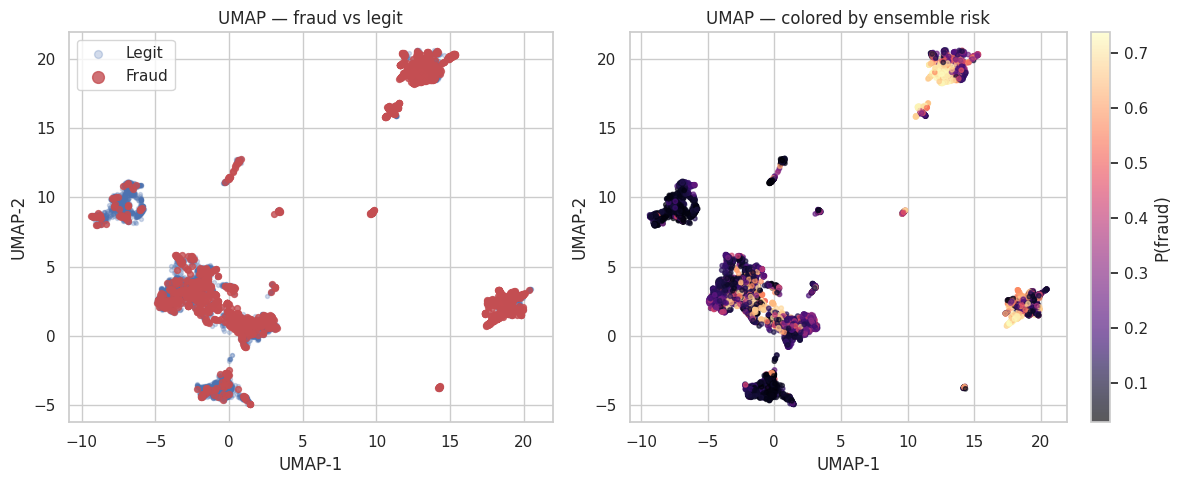

In [31]:
X_umap = None
if HAS_UMAP:
    print("UMAP fitting...", flush=True)
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.15, n_components=2,
                        metric="euclidean", random_state=42, low_memory=True)
    X_umap = reducer.fit_transform(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax = axes[0]
    ax.scatter(X_umap[leg, 0], X_umap[leg, 1], c="#4C72B0", s=8, alpha=0.25, label="Legit", rasterized=True)
    ax.scatter(X_umap[fr, 0], X_umap[fr, 1], c="#C44E52", s=18, alpha=0.8, label="Fraud", rasterized=True)
    ax.set_title("UMAP — fraud vs legit")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.legend(markerscale=2)

    ax = axes[1]
    sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=risk_viz, cmap="magma", s=10, alpha=0.65, rasterized=True)
    plt.colorbar(sc, ax=ax, fraction=0.046, label="P(fraud)")
    ax.set_title("UMAP — colored by ensemble risk")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/umap_fraud.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("!pip install umap-learn  then re-run this cell")


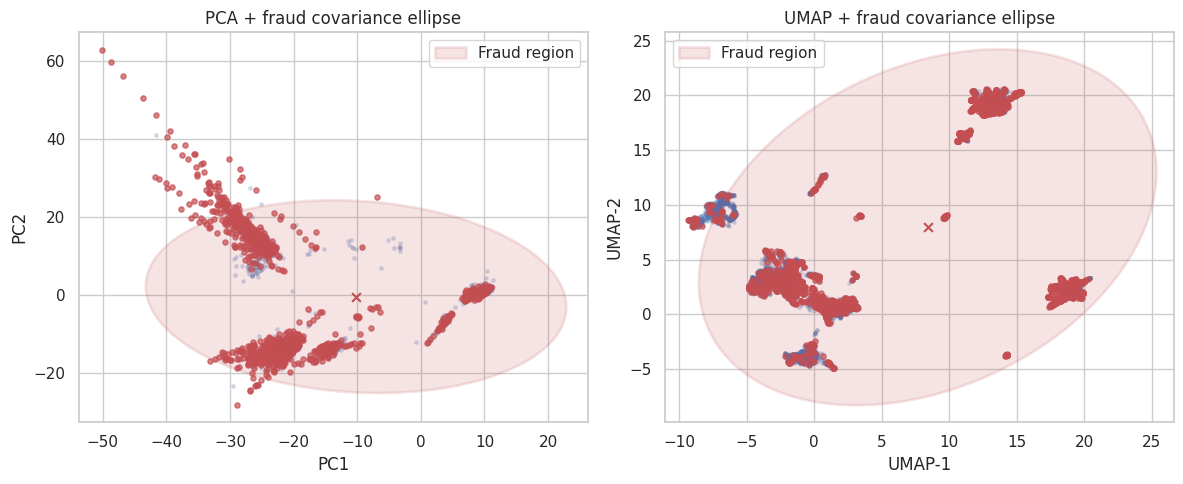

Saved fraud_ellipse.png


In [32]:
def fraud_ellipse(ax, XY, y, label="Fraud region"):
    pts = XY[y == 1]
    if len(pts) < 10:
        return
    cov = EmpiricalCovariance().fit(pts)
    vals, vecs = np.linalg.eigh(cov.covariance_)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * 2 * np.sqrt(np.maximum(vals, 1e-9))
    center = pts.mean(axis=0)
    ell = Ellipse(xy=center, width=width, height=height, angle=theta,
                  edgecolor="#C44E52", facecolor="#C44E52", alpha=0.15, lw=2, label=label)
    ax.add_patch(ell)
    ax.scatter([center[0]], [center[1]], c="#C44E52", s=40, marker="x", zorder=5)

n_plots = 2 if X_umap is not None else 1
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

ax = axes[0]
ax.scatter(X_pca[leg, 0], X_pca[leg, 1], c="#4C72B0", s=6, alpha=0.2, rasterized=True)
ax.scatter(X_pca[fr, 0], X_pca[fr, 1], c="#C44E52", s=14, alpha=0.7, rasterized=True)
fraud_ellipse(ax, X_pca, y_viz)
ax.set_title("PCA + fraud covariance ellipse")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(loc="best")

if X_umap is not None:
    ax = axes[1]
    ax.scatter(X_umap[leg, 0], X_umap[leg, 1], c="#4C72B0", s=6, alpha=0.2, rasterized=True)
    ax.scatter(X_umap[fr, 0], X_umap[fr, 1], c="#C44E52", s=14, alpha=0.7, rasterized=True)
    fraud_ellipse(ax, X_umap, y_viz)
    ax.set_title("UMAP + fraud covariance ellipse")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.legend(loc="best")

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/fraud_ellipse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fraud_ellipse.png")


## 8. Cost-sensitive APPROVE / REVIEW / BLOCK + budgets


Hypothetical cost analysis on ENSEMBLE scores (not bank ground truth):

S1_10x: OPT cost=4582 capture=0.910 review=0.200 | CONV cost=8631 capture=0.673
S2_25x: OPT cost=7135 capture=0.931 review=0.253 | CONV cost=20076 capture=0.673
S3_50x: OPT cost=9306 capture=0.965 review=0.426 | CONV cost=39151 capture=0.673


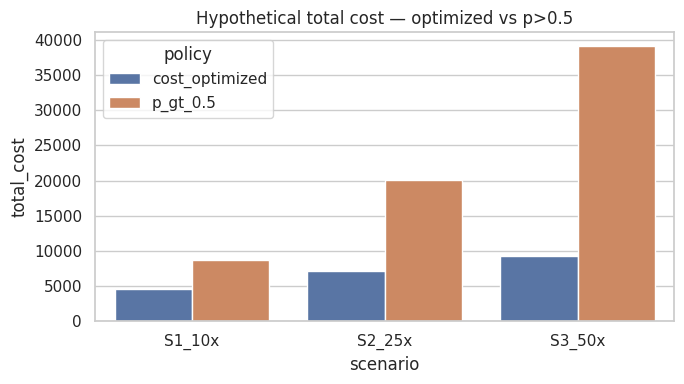


FC@budget (ensemble):
  FC@1%: 0.245
  FC@5%: 0.699
  FC@10%: 0.814


In [33]:
def expected_cost(y_true, proba, tau1, tau2, c_fn, c_fp, c_review):
    action = np.where(proba < tau1, "APPROVE", np.where(proba < tau2, "REVIEW", "BLOCK"))
    cost = np.zeros(len(y_true))
    cost[(action == "APPROVE") & (y_true == 1)] = c_fn
    cost[(action == "BLOCK") & (y_true == 0)] = c_fp
    cost[action == "REVIEW"] = c_review
    return {
        "tau1": float(tau1), "tau2": float(tau2), "total_cost": float(cost.sum()),
        "fraud_capture": float(y_true[action != "APPROVE"].sum() / max(y_true.sum(), 1)),
        "review_rate": float((action == "REVIEW").mean()),
        "false_decline_rate": float(((action == "BLOCK") & (y_true == 0)).sum() / max((y_true == 0).sum(), 1)),
    }

def optimize_thresholds(y_true, proba, c_fn, c_fp, c_review, grid=41):
    taus = np.linspace(0.01, 0.99, grid)
    best = None
    for t1 in taus:
        for t2 in taus:
            if t2 <= t1:
                continue
            r = expected_cost(y_true, proba, t1, t2, c_fn, c_fp, c_review)
            if best is None or r["total_cost"] < best["total_cost"]:
                best = r
    return best

# use ensemble proba for operational layer
e6_rows = []
print("Hypothetical cost analysis on ENSEMBLE scores (not bank ground truth):\n")
for name, cfn in [("S1_10x", 10.0), ("S2_25x", 25.0), ("S3_50x", 50.0)]:
    opt = optimize_thresholds(y_test, ens_proba, cfn, 1.0, 0.2)
    conv = expected_cost(y_test, ens_proba, 0.5, 0.5 + 1e-9, cfn, 1.0, 0.2)
    opt["scenario"] = name
    opt["policy"] = "cost_optimized"
    conv["scenario"] = name
    conv["policy"] = "p_gt_0.5"
    e6_rows += [opt, conv]
    print(f"{name}: OPT cost={opt['total_cost']:.0f} capture={opt['fraud_capture']:.3f} review={opt['review_rate']:.3f} | "
          f"CONV cost={conv['total_cost']:.0f} capture={conv['fraud_capture']:.3f}")

df_e6 = pd.DataFrame(e6_rows)
df_e6.to_csv(f"{CONFIG['output_dir']}/E6_cost.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = df_e6.copy()
sns.barplot(data=plot_df, x="scenario", y="total_cost", hue="policy", ax=ax)
ax.set_title("Hypothetical total cost — optimized vs p>0.5")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/E6_cost_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFC@budget (ensemble):")
for k, v in fc_at_budget(y_test, ens_proba).items():
    print(f"  {k}: {v:.3f}")


## 9. Optional SHAP (best model, one seed)


Fitting one LGBM for SHAP...


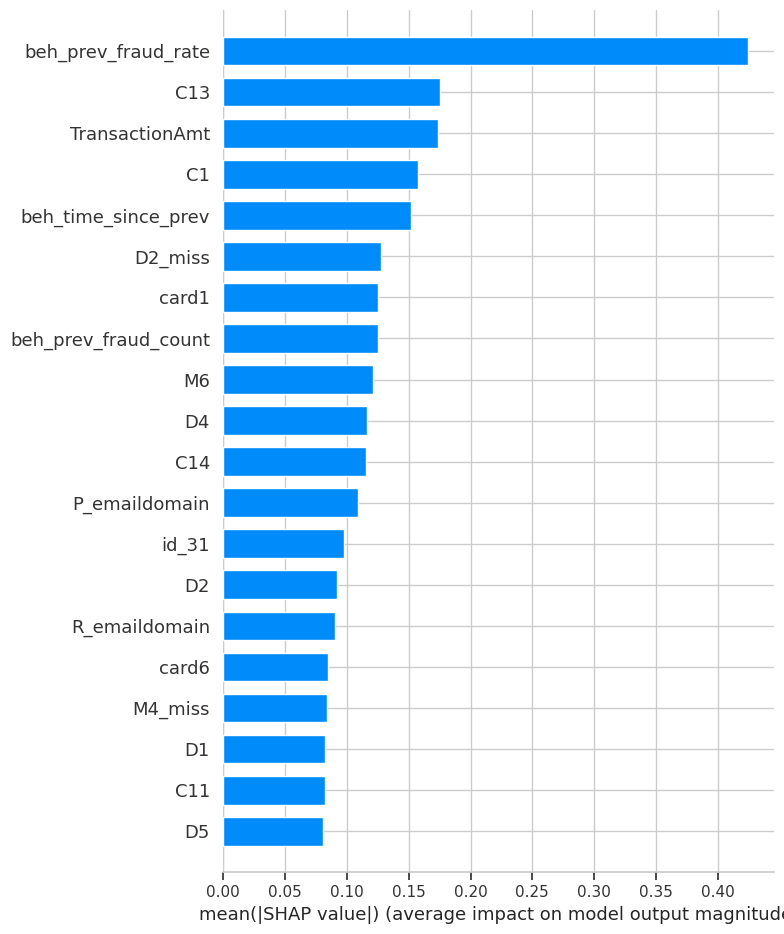

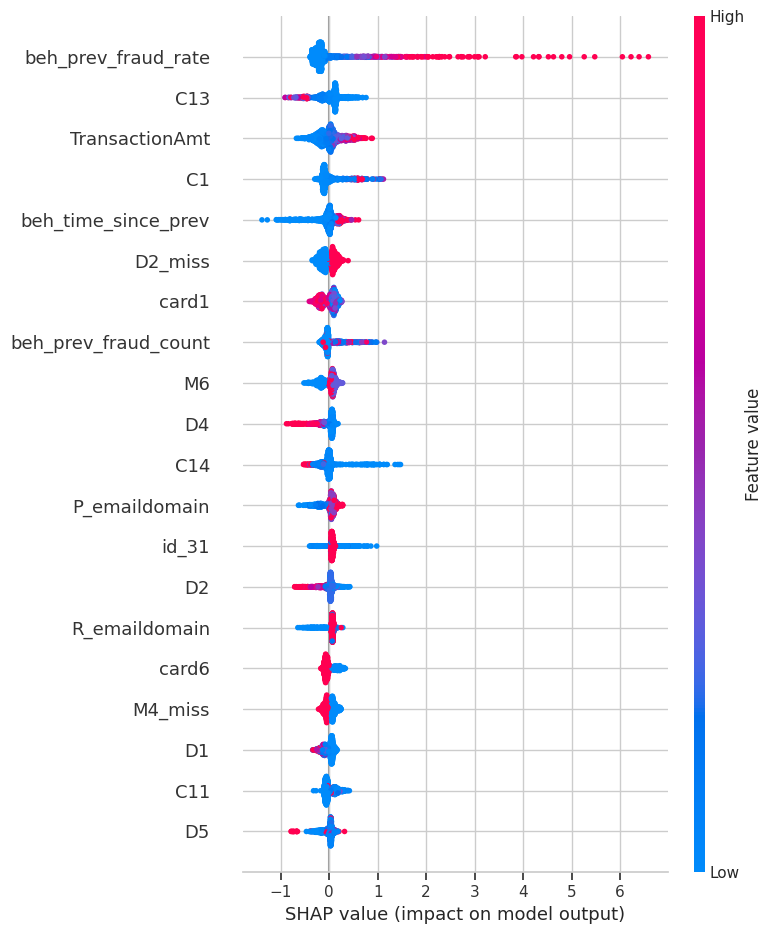

In [34]:
if HAS_SHAP and HAS_LGB:
    print("Fitting one LGBM for SHAP...", flush=True)
    m = lgb.LGBMClassifier(
        n_estimators=400, num_leaves=63, learning_rate=0.03,
        subsample=0.85, colsample_bytree=0.7, scale_pos_weight=pos_w,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    m.fit(X_train, y_train)
    sample = X_test.sample(n=min(1200, len(X_test)), random_state=42)
    explainer = shap.TreeExplainer(m)
    sv = explainer.shap_values(sample)
    if isinstance(sv, list):
        sv = sv[1]
    shap.summary_plot(sv, sample, plot_type="bar", show=True)
    shap.summary_plot(sv, sample, show=True)
else:
    print("SHAP skipped (need shap + lightgbm)")


## 10. Final JSON export


In [35]:
summary = {
    "meta": {
        "sample_n_ieee": CONFIG["SAMPLE_N_IEEE"],
        "seeds": SEEDS,
        "n_features": int(X_train.shape[1]),
        "threshold_rule": "VAL max-F1, applied to TEST",
        "note": "E6 costs are hypothetical sensitivity analysis.",
    },
    "mean_std_by_model": df_mean_std.to_dict(orient="records"),
    "ensemble_test": {k: (round(v, 6) if isinstance(v, float) else v) for k, v in ens.items()},
    "best_model_by_mean_pr_auc": best_model,
}
path = Path(CONFIG["output_dir"]) / "prefinal_summary.json"
with open(path, "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))
print("\nSaved", path)
print("Artifacts in", CONFIG["output_dir"])
print(os.listdir(CONFIG["output_dir"]))


{
  "meta": {
    "sample_n_ieee": 300000,
    "seeds": [
      42,
      7,
      123,
      2024,
      99
    ],
    "n_features": 662,
    "threshold_rule": "VAL max-F1, applied to TEST",
    "note": "E6 costs are hypothetical sensitivity analysis."
  },
  "mean_std_by_model": [
    {
      "model": "LightGBM",
      "PR_AUC": "0.5562 \u00b1 0.0097",
      "ROC_AUC": "0.9349 \u00b1 0.0012",
      "Precision": "0.6055 \u00b1 0.0490",
      "Recall": "0.5416 \u00b1 0.0343",
      "F1": "0.5696 \u00b1 0.0141",
      "MCC": "0.5553 \u00b1 0.0149",
      "FC@1%": "0.2090 \u00b1 0.0060",
      "FC@5%": "0.6257 \u00b1 0.0135",
      "FC@10%": "0.7778 \u00b1 0.0151",
      "threshold": "0.1991 \u00b1 0.0040"
    },
    {
      "model": "RandomForest",
      "PR_AUC": "0.6172 \u00b1 0.0053",
      "ROC_AUC": "0.9265 \u00b1 0.0005",
      "Precision": "0.5910 \u00b1 0.0415",
      "Recall": "0.5700 \u00b1 0.0250",
      "F1": "0.5788 \u00b1 0.0076",
      "MCC": "0.5629 \u00b1 0.0094",
     

## How to run

1. Optional: `!pip install umap-learn shap`
2. Run all cells top → bottom
3. For paper full data: `SAMPLE_N_IEEE = None` on high-RAM, keep LGBM+XGB (RF may be slow)

**Interpretation reminder**
- ROC-AUC ~0.93 = strong ranking
- PR-AUC ~0.55 = normal under temporal split + rare fraud
- MCC/F1 only valid with VAL-tuned threshold (this notebook does that)
- PCA/UMAP are illustrative geometry, not performance proof
